In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv("data.csv")
X = data.drop(columns=['id','diagnosis']).values
y = data['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

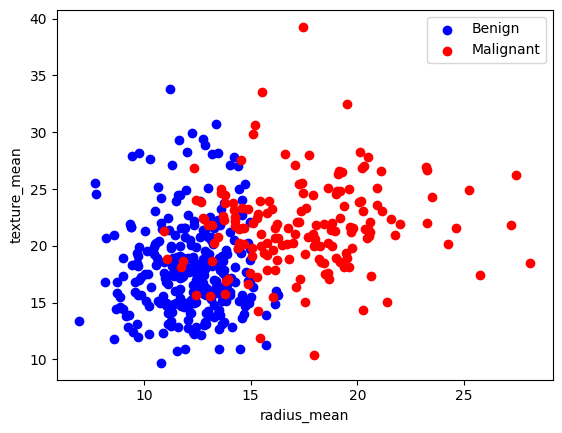

In [4]:
plt.scatter(X_train[y_train=='B',0] , X_train[y_train=='B',1], color='blue', label='Benign')
plt.scatter(X_train[y_train=='M',0] , X_train[y_train=='M',1], color='red', label='Malignant')
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.legend()
plt.show()

In [6]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

class KNN:
    def __init__(self, k):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self,new_data):
        predicted_labels = [self._predict(x) for x in new_data]
        return np.array(predicted_labels)   

    def _predict(self,new_data):
        distances = [euclidean_distance(new_data, x_train) for x_train in self.X_train]

        k_nearest_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [10]:
knn = KNN(k=7)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
accuracy = np.mean(predictions == y_test) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 60.53%
